Jupyter Notebook for the Kaggle Competition (Machine Learning - CentraleSupélec - January 2025)  
PAES DE ALMEIDA NINA DUARTE, Pedro ; COLLIER, Grégoire ; PERARDT MAGALHÃES BRITO, Romero

Import necessary packages

In [169]:
import geopandas as gpd
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score

from sklearn.metrics import accuracy_score

Import data 

In [170]:
change_type_map = {'Demolition': 0, 'Road': 1, 'Residential': 2, 'Commercial': 3, 'Industrial': 4,
                   'Mega Projects': 5}

## Read csvs

train_df = gpd.read_file('train.geojson', index_col=0)
test_df = gpd.read_file('test.geojson', index_col=0)

train_y = train_df['change_type'].apply(lambda x: change_type_map[x])

submission_df = pd.DataFrame(test_df['index'])

c:\Users\pedro\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GeoJSON does not support open option INDEX_COL
  return ogr_read(
c:\Users\pedro\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GeoJSON does not support open option INDEX_COL
  return ogr_read(


Fill continuous-valued columns NaNs with mean and MinMax scale them

In [171]:
ignore_columns = ['urban_type', 'geography_type', 'change_type','date0', 'change_status_date0', 'date1',
                   'change_status_date1','date2', 'change_status_date2','date3', 'change_status_date3', 
                   'date4', 'change_status_date4', 'index', 'geometry']

for col in train_df.columns:
    if col not in ignore_columns:
        train_df[col].fillna(train_df[col].mean(), inplace=True)


numeric_columns = ['img_red_mean_date1',
       'img_green_mean_date1', 'img_blue_mean_date1', 'img_red_std_date1',
       'img_green_std_date1', 'img_blue_std_date1', 'img_red_mean_date2',
       'img_green_mean_date2', 'img_blue_mean_date2', 'img_red_std_date2',
       'img_green_std_date2', 'img_blue_std_date2', 'img_red_mean_date3',
       'img_green_mean_date3', 'img_blue_mean_date3', 'img_red_std_date3',
       'img_green_std_date3', 'img_blue_std_date3', 'img_red_mean_date4',
       'img_green_mean_date4', 'img_blue_mean_date4', 'img_red_std_date4',
       'img_green_std_date4', 'img_blue_std_date4', 'img_red_mean_date5',
       'img_green_mean_date5', 'img_blue_mean_date5', 'img_red_std_date5',
       'img_green_std_date5', 'img_blue_std_date5']

for column in numeric_columns:
    train_df[column] = (train_df[column] - train_df[column].min()) / (train_df[column].max() - train_df[column].min())

C:\Users\pedro\AppData\Local\Temp\ipykernel_23096\2828756675.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].mean(), inplace=True)


Fill missing dates with closest date (one above)

In [172]:
# Foward fill

train_df['date0'].fillna(method='ffill', inplace=True)
train_df['date1'].fillna(method='ffill', inplace=True)
train_df['date2'].fillna(method='ffill', inplace=True)
train_df['date3'].fillna(method='ffill', inplace=True)
train_df['date4'].fillna(method='ffill', inplace=True)

C:\Users\pedro\AppData\Local\Temp\ipykernel_23096\492714978.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['date0'].fillna(method='ffill', inplace=True)
C:\Users\pedro\AppData\Local\Temp\ipykernel_23096\492714978.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df['date0'].fillna(method='ffill', inplace=True)
C:\Users\pedro\AppData\Local\Temp\ipykernel_23096\492714978.py:4: FutureWarning: A value is trying to be set 

Treat 'N,A' in 'urban_type' and 'geography_type' column

In [173]:
## Used codes for urban_type and geography_type
""" train_df[train_df['urban_type'] == 'N,A']
train_df[train_df['geography_type'].str.contains('Snow')]['urban_type'].value_counts()
train_df['urban_type'].value_counts()  """

" train_df[train_df['urban_type'] == 'N,A']\ntrain_df[train_df['geography_type'].str.contains('Snow')]['urban_type'].value_counts()\ntrain_df['urban_type'].value_counts()  "

In [174]:
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Dense Forest|Farms"))), 'urban_type'] = 'Rural'
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Barren Land"))), 'urban_type'] = 'Urban'
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Sparse Forest"))), 'urban_type'] = 'Sparse Urban'


## Costal had 3545 N,A, 136 Industrial, 32 Sparse Urban and 19 Dense Urban
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Coastal"))), 'urban_type'] = 'Industrial'

## River had 664 Industrial, 215 Dense Urban and 115 N,A
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("River"))), 'urban_type'] = 'Industrial'

## Desert had 1520 N,A, 1350 Industrial, 1257 Sparse Urban and 940 Dense Urban
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Desert"))), 'urban_type'] = 'Industrial'

## Lakes or Green Land had 15669 Sparse Urban and 237 N,A
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Lakes|Green Land"))), 'urban_type'] = 'Sparse Urban'

## Grass Land had 41861 Dense Urban, 33048 Sparse Urban and 271 N,A
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Grass Land"))), 'urban_type'] = 'Dense Urban'

## Snow had 4 Sparse Urban, 3 Dense Urban and 3 N,A
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Snow"))), 'urban_type'] = 'Sparse Urban'

In [175]:
## Unideal substitution
train_df.loc[train_df['geography_type'] == 'N,A', 'geography_type'] = 'Sparse Forest'
train_df.loc[train_df['geography_type'] == None, 'geography_type'] = 'Sparse Urban'

In [176]:
from datetime import datetime
date_format = "%d-%m-%Y"

for column in ['date0', 'date1', 'date2', 'date3', 'date4']:
    train_df[column] = train_df[column].apply(lambda x: datetime.strptime(x,date_format))

In [177]:
""" print((train_df['date0']>train_df['date1']).sum())
print((train_df['date1']>train_df['date2']).sum())
print((train_df['date2']>train_df['date3']).sum())
print((train_df['date3']>train_df['date4']).sum()) """

" print((train_df['date0']>train_df['date1']).sum())\nprint((train_df['date1']>train_df['date2']).sum())\nprint((train_df['date2']>train_df['date3']).sum())\nprint((train_df['date3']>train_df['date4']).sum()) "

In [178]:
# Specify the columns that should be sorted (col1 to col8 in this case)
cols_to_sort = ['date0','change_status_date0','date1','change_status_date1','date2','change_status_date2','date3','change_status_date3', 'date4','change_status_date4']


# Function to sort only the selected columns
def sort_selected_columns_numpy(row):
    num_values = np.array(row[cols_to_sort[::2]])  # Extract numeric values
    str_values = np.array(row[cols_to_sort[1::2]])  # Extract paired strings
    sorted_indices = np.argsort(num_values)  # Get sorting order
    
    # Rearrange both numeric and string values based on sorted indices
    sorted_nums = num_values[sorted_indices]
    sorted_strs = str_values[sorted_indices]
    
    # Flatten and reassign the sorted values back to the row
    row[cols_to_sort] = np.column_stack((sorted_nums, sorted_strs)).flatten()
    return row

# Apply function row-wise
train_df = train_df.apply(sort_selected_columns_numpy, axis=1)


Start encoding the categorical labels


In [179]:
urban_types = list(train_df['urban_type'].unique())
unique_urban_types = []

for type in urban_types:
    #print(type, type.split(','))
    unique_urban_types += type.split(',')
unique_urban_types = set(unique_urban_types)
#print(unique_urban_types)


geo_types = list(train_df['geography_type'].unique())
unique_geo_types = []

for type in geo_types:
    #print(type, type.split(','))
    unique_geo_types += type.split(',')
unique_geo_types = set(unique_geo_types)
#print(unique_geo_types)

In [180]:
train_df['urban_type'] = train_df['urban_type'].apply(lambda x: x.split(','))
train_df['geography_type'] = train_df['geography_type'].apply(lambda x: x.split(','))

In [181]:
for unique_geo_type in unique_geo_types:
    train_df[unique_geo_type] = train_df['geography_type'].apply(lambda x: 1 if unique_geo_type in x else 0)
for unique_urban_type in unique_urban_types:
    train_df[unique_urban_type] = train_df['urban_type'].apply(lambda x: 1 if unique_urban_type in x else 0)

In [182]:
""" for column in train_df.columns:
    print(column) """

' for column in train_df.columns:\n    print(column) '

Drop index column since it's irrelevant

In [183]:
train_df.drop('index', axis = 1, inplace=True)

Encoding the 'change_status_datex' columns

In [184]:
status = []
for column in ['change_status_date0', 'change_status_date1', 'change_status_date2', 'change_status_date3', 'change_status_date4']:
    status += list(train_df[column].unique())
status = set(status)
""" for element in status:
    print(element)
 """
change_status_map = {'Materials Dumped': 2, 'Construction Done': 7, 'Construction Midway':6, 'Construction Started': 5, 'Greenland': 0, 'Prior Construction': 9,
                   'Land Cleared': 1,'Materials Introduced':4, 'Excavation': 3,'Operational': 8, None: 4.5}

train_df['change_status_date0'] = train_df['change_status_date0'].apply(lambda x: change_status_map[x])
train_df['change_status_date1'] = train_df['change_status_date1'].apply(lambda x: change_status_map[x])
train_df['change_status_date2'] = train_df['change_status_date2'].apply(lambda x: change_status_map[x])
train_df['change_status_date3'] = train_df['change_status_date3'].apply(lambda x: change_status_map[x])
train_df['change_status_date4'] = train_df['change_status_date4'].apply(lambda x: change_status_map[x])

Get area and length of polygon and drop the geometry column

In [185]:
train_df['area'] = train_df['geometry'].area
train_df['length'] = train_df['geometry'].length
train_df.drop('geometry', axis = 1, inplace=True)

C:\Users\pedro\AppData\Local\Temp\ipykernel_23096\3326062253.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  train_df['area'] = train_df['geometry'].area
C:\Users\pedro\AppData\Local\Temp\ipykernel_23096\3326062253.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  train_df['length'] = train_df['geometry'].length


In [186]:
#train_df.columns

Create columns with the difference of time passed between changes in status

In [187]:
time_diffs = ['time_diff_1','time_diff_2','time_diff_3']
dates = ['date0', 'date1', 'date2', 'date3', 'date4']
for i in range(3):
    train_df[time_diffs[i]] = train_df[dates[i+1]] - train_df[dates[i]]
    train_df[time_diffs[i]] = train_df[time_diffs[i]].apply(lambda x: x.days)

In [188]:
train_df.drop(dates, axis=1, inplace = True)

Final preprocessed DataFrame 

In [189]:
preprocessed_df = train_df.drop(['urban_type', 'geography_type', 'change_type'], axis=1)

In [190]:
X_train, X_test, y_train, y_test = train_test_split(preprocessed_df, train_y, train_size=0.7, random_state = 0)

from sklearn.tree import DecisionTreeClassifier
dtree_model = DecisionTreeClassifier(max_depth = 30).fit(X_train, y_train)
dtree_predictions = dtree_model.predict(X_test)

# creating a confusion matrix
cm = confusion_matrix(y_test, dtree_predictions)

accuracy_dtree = accuracy_score(y_test, dtree_predictions)
score = f1_score(y_test, dtree_predictions, average = 'macro')
cm

array([[ 7038,    59,  1422,   891,    10,     1],
       [   58,  2097,   827,  1314,    18,     4],
       [ 1687,   833, 31692, 10157,   136,    11],
       [  897,  1479, 10481, 17047,   228,    24],
       [   16,    18,   129,   199,    29,     1],
       [    1,     4,    21,    14,     0,     1]], dtype=int64)

In [191]:
accuracy_dtree

0.6517491333123228

In [192]:
score

0.43161408652103

Replicate steps above for test set by creating a pipeline similar to steps above

In [193]:
def pipeline(train_df):
    for col in train_df.columns:
        if col not in ignore_columns:
            train_df[col].fillna(train_df[col].mean(), inplace=True)

    for column in numeric_columns:
        train_df[column] = (train_df[column] - train_df[column].min()) / (train_df[column].max() - train_df[column].min())

    train_df['date0'].fillna(method='ffill', inplace=True)
    train_df['date1'].fillna(method='ffill', inplace=True)
    train_df['date2'].fillna(method='ffill', inplace=True)
    train_df['date3'].fillna(method='ffill', inplace=True)
    train_df['date4'].fillna(method='ffill', inplace=True)

    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Dense Forest|Farms"))), 'urban_type'] = 'Rural'
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Barren Land"))), 'urban_type'] = 'Urban'
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Sparse Forest"))), 'urban_type'] = 'Sparse Urban'


    ## Costal had 3545 N,A, 136 Industrial, 32 Sparse Urban and 19 Dense Urban
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Coastal"))), 'urban_type'] = 'Industrial'

    ## River had 664 Industrial, 215 Dense Urban and 115 N,A
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("River"))), 'urban_type'] = 'Industrial'

    ## Desert had 1520 N,A, 1350 Industrial, 1257 Sparse Urban and 940 Dense Urban
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Desert"))), 'urban_type'] = 'Industrial'

    ## Lakes or Green Land had 15669 Sparse Urban and 237 N,A
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Lakes|Green Land"))), 'urban_type'] = 'Sparse Urban'

    ## Grass Land had 41861 Dense Urban, 33048 Sparse Urban and 271 N,A
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Grass Land"))), 'urban_type'] = 'Dense Urban'

    ## Snow had 4 Sparse Urban, 3 Dense Urban and 3 N,A
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Snow"))), 'urban_type'] = 'Sparse Urban'

    ## Unideal substitution
    train_df.loc[train_df['geography_type'] == 'N,A', 'geography_type'] = 'Sparse Forest'
    train_df.loc[train_df['geography_type'] == None, 'geography_type'] = 'Sparse Urban'

    date_format = "%d-%m-%Y"

    for column in ['date0', 'date1', 'date2', 'date3', 'date4']:
        train_df[column] = train_df[column].apply(lambda x: datetime.strptime(x,date_format))
    # Specify the columns that should be sorted (col1 to col8 in this case)
    cols_to_sort = ['date0','change_status_date0','date1','change_status_date1','date2','change_status_date2','date3','change_status_date3', 'date4','change_status_date4']


    # Function to sort only the selected columns
    def sort_selected_columns_numpy(row):
        num_values = np.array(row[cols_to_sort[::2]])  # Extract numeric values
        str_values = np.array(row[cols_to_sort[1::2]])  # Extract paired strings
        sorted_indices = np.argsort(num_values)  # Get sorting order
        
        # Rearrange both numeric and string values based on sorted indices
        sorted_nums = num_values[sorted_indices]
        sorted_strs = str_values[sorted_indices]
        
        # Flatten and reassign the sorted values back to the row
        row[cols_to_sort] = np.column_stack((sorted_nums, sorted_strs)).flatten()
        return row

    # Apply function row-wise
    train_df = train_df.apply(sort_selected_columns_numpy, axis=1)
    
    train_df.drop('index', axis = 1, inplace=True)

    """ urban_types = list(train_df['urban_type'].unique())
    unique_urban_types = []
    for type in urban_types:
        #print(type, type.split(','))
        unique_urban_types += type.split(',')
    unique_urban_types = set(unique_urban_types)
    #print(unique_urban_types)

    geo_types = list(train_df['geography_type'].unique())
    unique_geo_types = []
    for type in geo_types:
        #print(type, type.split(','))
        unique_geo_types += type.split(',')
    unique_geo_types = set(unique_geo_types)
    #print(unique_geo_types) """
    
    train_df['urban_type'] = train_df['urban_type'].apply(lambda x: x.split(','))
    train_df['geography_type'] = train_df['geography_type'].apply(lambda x: x.split(','))

    for unique_geo_type in unique_geo_types:
        train_df[unique_geo_type] = train_df['geography_type'].apply(lambda x: 1 if unique_geo_type in x else 0)
    for unique_urban_type in unique_urban_types:
        train_df[unique_urban_type] = train_df['urban_type'].apply(lambda x: 1 if unique_urban_type in x else 0)


    change_status_map = {'Materials Dumped': 2, 'Construction Done': 7, 'Construction Midway':6, 'Construction Started': 5, 'Greenland': 0, 'Prior Construction': 9,
                    'Land Cleared': 1,'Materials Introduced':4, 'Excavation': 3,'Operational': 8, None: 4.5}

    train_df['change_status_date0'] = train_df['change_status_date0'].apply(lambda x: change_status_map[x])
    train_df['change_status_date1'] = train_df['change_status_date1'].apply(lambda x: change_status_map[x])
    train_df['change_status_date2'] = train_df['change_status_date2'].apply(lambda x: change_status_map[x])
    train_df['change_status_date3'] = train_df['change_status_date3'].apply(lambda x: change_status_map[x])
    train_df['change_status_date4'] = train_df['change_status_date4'].apply(lambda x: change_status_map[x])

    train_df['area'] = train_df['geometry'].area
    train_df['length'] = train_df['geometry'].length
    train_df.drop('geometry', axis = 1, inplace=True)


    time_diffs = ['time_diff_1','time_diff_2','time_diff_3']
    dates = ['date0', 'date1', 'date2', 'date3', 'date4']
    for i in range(3):
        train_df[time_diffs[i]] = train_df[dates[i+1]] - train_df[dates[i]]
        train_df[time_diffs[i]] = train_df[time_diffs[i]].apply(lambda x: x.days)


    preprocessed_df = train_df.drop(dates, axis=1)
    preprocessed_df.drop(['urban_type', 'geography_type'], axis=1, inplace=True)

    return preprocessed_df

preprocessed_test_df = pipeline(test_df)

C:\Users\pedro\AppData\Local\Temp\ipykernel_23096\1546301114.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].mean(), inplace=True)
C:\Users\pedro\AppData\Local\Temp\ipykernel_23096\1546301114.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


In [194]:
preprocessed_df.columns

Index(['img_red_mean_date1', 'img_green_mean_date1', 'img_blue_mean_date1',
       'img_red_std_date1', 'img_green_std_date1', 'img_blue_std_date1',
       'img_red_mean_date2', 'img_green_mean_date2', 'img_blue_mean_date2',
       'img_red_std_date2', 'img_green_std_date2', 'img_blue_std_date2',
       'img_red_mean_date3', 'img_green_mean_date3', 'img_blue_mean_date3',
       'img_red_std_date3', 'img_green_std_date3', 'img_blue_std_date3',
       'img_red_mean_date4', 'img_green_mean_date4', 'img_blue_mean_date4',
       'img_red_std_date4', 'img_green_std_date4', 'img_blue_std_date4',
       'img_red_mean_date5', 'img_green_mean_date5', 'img_blue_mean_date5',
       'img_red_std_date5', 'img_green_std_date5', 'img_blue_std_date5',
       'change_status_date0', 'change_status_date1', 'change_status_date2',
       'change_status_date3', 'change_status_date4', 'Dense Forest', 'Coastal',
       'Hills', 'Desert', 'Sparse Forest', 'Barren Land', 'Lakes', 'River',
       'Snow', 'Farms',

In [195]:
preprocessed_test_df.columns

Index(['img_red_mean_date1', 'img_green_mean_date1', 'img_blue_mean_date1',
       'img_red_std_date1', 'img_green_std_date1', 'img_blue_std_date1',
       'img_red_mean_date2', 'img_green_mean_date2', 'img_blue_mean_date2',
       'img_red_std_date2', 'img_green_std_date2', 'img_blue_std_date2',
       'img_red_mean_date3', 'img_green_mean_date3', 'img_blue_mean_date3',
       'img_red_std_date3', 'img_green_std_date3', 'img_blue_std_date3',
       'img_red_mean_date4', 'img_green_mean_date4', 'img_blue_mean_date4',
       'img_red_std_date4', 'img_green_std_date4', 'img_blue_std_date4',
       'img_red_mean_date5', 'img_green_mean_date5', 'img_blue_mean_date5',
       'img_red_std_date5', 'img_green_std_date5', 'img_blue_std_date5',
       'change_status_date0', 'change_status_date1', 'change_status_date2',
       'change_status_date3', 'change_status_date4', 'Dense Forest', 'Coastal',
       'Hills', 'Desert', 'Sparse Forest', 'Barren Land', 'Lakes', 'River',
       'Snow', 'Farms',

In [196]:
preprocessed_test_df = preprocessed_test_df[preprocessed_df.columns]

In [197]:
dtree_predictions_kaggle = dtree_model.predict(preprocessed_test_df)
dtree_predictions_kaggle

submission_df['change_type'] = dtree_predictions_kaggle
submission_df = submission_df.rename(columns={'index': 'Id', 'change_type': 'change_type'})
submission_df

,Id,change_type
0,0,3
1,1,3
2,2,1
3,3,3
4,4,0
...,...,...
120521,120521,3
120522,120522,3
120523,120523,1
120524,120524,1


Create csv for submission

In [198]:
from pathlib import Path  
filepath = Path('./submission.csv')  
filepath.parent.mkdir(parents=True, exist_ok=True)  
submission_df.to_csv(filepath, columns=['Id', 'change_type'], index=False) 

New model w/ OneVsRest + SVC

In [199]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC

X_train, X_test, y_train, y_test = train_test_split(preprocessed_df, train_y, train_size=0.3, random_state = 0)

model = OneVsRestClassifier(LinearSVC(random_state=0)).fit(X_train, y_train)
predictions = model.predict(X_test)

# creating a confusion matrix
cm = confusion_matrix(y_test, predictions)

accuracy = accuracy_score(y_test, predictions)
score = f1_score(y_test, predictions, average = 'macro')
cm

array([[19455,     0,  1447,  1157,     0,     0],
       [   63,     0,  7086,  2971,     0,     0],
       [ 4173,     0, 84595, 15136,     0,     0],
       [ 1943,     0, 39382, 28881,     0,     0],
       [   31,     0,   540,   336,     0,     0],
       [    4,     0,    66,    37,     0,     0]], dtype=int64)

In [200]:
score

0.33593161727083515

In [201]:
accuracy

0.6412401171232447

In [219]:
svc_predictions_kaggle = model.predict(preprocessed_test_df)

submission_df_svc = pd.DataFrame(svc_predictions_kaggle, columns=['change_type'])
submission_df_svc.insert(0, 'Id', submission_df['Id'])

from pathlib import Path  
filepath = Path('./submission_svc.csv')  
filepath.parent.mkdir(parents=True, exist_ok=True)  
submission_df_svc.to_csv(filepath, columns=['Id', 'change_type'], index=False) 

PyTorch Model

In [202]:
import torch
from torch import nn
from torch.utils.data import DataLoader

In [203]:
X_data = preprocessed_df.to_numpy()
y_data = train_y.to_numpy()
X_final_test = preprocessed_test_df.to_numpy()

X_data = torch.from_numpy(X_data).type(torch.float)
y_data = torch.from_numpy(y_data).type(torch.float)
X_final_test = torch.from_numpy(X_final_test).type(torch.float)

In [204]:
X_train_pt, X_test_pt, y_train_pt, y_test_pt = train_test_split(X_data, y_data, test_size=0.30, random_state=101)

In [205]:
model_pt = nn.Sequential(
    nn.Linear(in_features=X_train_pt.shape[1], out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=512),
    nn.ReLU(),
    nn.Linear(in_features=512, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=6)
    )

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_pt.parameters(),
                            lr = 0.001)

In [206]:
from torcheval.metrics.functional import multiclass_f1_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [207]:
y_train_pt = y_train_pt.type(torch.LongTensor)
y_test_pt = y_test_pt.type(torch.LongTensor)

In [208]:
epochs = 100
train_loss = []
test_loss = []
epoch_count = []

for epoch in range(epochs):
    epoch_count.append(epoch)

    ### Train model

    model_pt.train()

    #y_pred_train = torch.round(torch.sigmoid(model_pt(X_train_pt)))
    y_pred_train = model_pt(X_train_pt)

    loss = loss_fn(y_pred_train, y_train_pt)

    train_loss.append(loss)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    ### Evalualte model

    model_pt.eval()

    with torch.inference_mode():
        y_pred_test = model_pt(X_test_pt)

    loss_test = loss_fn(y_pred_test, y_test_pt)
    test_loss.append(loss_test)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} ||| train loss {loss} ||| test loss {loss_test}")

Epoch 0 ||| train loss 4.827574729919434 ||| test loss 5.801261901855469
Epoch 10 ||| train loss 1.6927391290664673 ||| test loss 1.4309666156768799
Epoch 20 ||| train loss 1.1820298433303833 ||| test loss 1.1518359184265137
Epoch 30 ||| train loss 1.1525976657867432 ||| test loss 1.143917441368103
Epoch 40 ||| train loss 1.1352726221084595 ||| test loss 1.1352804899215698
Epoch 50 ||| train loss 1.1278541088104248 ||| test loss 1.127482295036316
Epoch 60 ||| train loss 1.1242992877960205 ||| test loss 1.1231632232666016
Epoch 70 ||| train loss 1.1203629970550537 ||| test loss 1.119101643562317
Epoch 80 ||| train loss 1.116115689277649 ||| test loss 1.1145063638687134
Epoch 90 ||| train loss 1.1115044355392456 ||| test loss 1.1099821329116821


In [209]:
import matplotlib.pyplot as plt

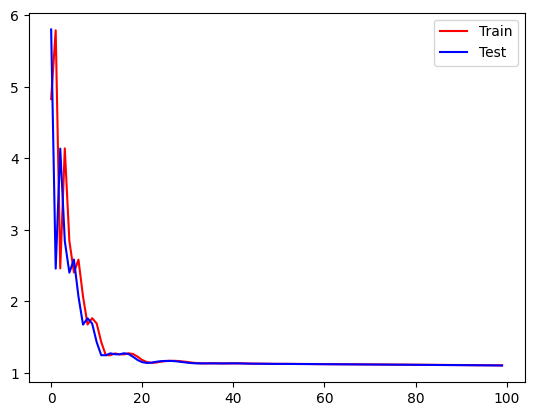

In [210]:
plt.plot(epoch_count, np.array(torch.tensor(train_loss).numpy()), label='Train', c='r')
plt.plot(epoch_count, np.array(torch.tensor(test_loss).numpy()), label='Test', c='b')
plt.legend()
plt.show()

In [211]:
predictions = model_pt(X_test_pt)

# creating a confusion matrix
cm = confusion_matrix(y_test_pt, np.array(torch.tensor(torch.argmax(predictions, axis=1)).numpy()))


accuracy = accuracy_score(y_test_pt,np.array(torch.tensor(torch.argmax(predictions, axis=1)).numpy()))
score = f1_score(y_test_pt, np.array(torch.tensor(torch.argmax(predictions, axis=1)).numpy()), average = 'macro')
cm

C:\Users\pedro\AppData\Local\Temp\ipykernel_23096\4204544409.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cm = confusion_matrix(y_test_pt, np.array(torch.tensor(torch.argmax(predictions, axis=1)).numpy()))
C:\Users\pedro\AppData\Local\Temp\ipykernel_23096\4204544409.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  accuracy = accuracy_score(y_test_pt,np.array(torch.tensor(torch.argmax(predictions, axis=1)).numpy()))
C:\Users\pedro\AppData\Local\Temp\ipykernel_23096\4204544409.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sc

array([[    0,     0,  6904,  2509,     0,     0],
       [    0,     0,  3140,  1142,     0,     0],
       [    0,     0, 39392,  5115,     0,     0],
       [    0,     0, 23606,  6593,     0,     0],
       [    0,     0,   365,    34,     0,     0],
       [    0,     0,    36,     8,     0,     0]], dtype=int64)

In [212]:
score

0.15951845179219068

In [213]:
accuracy

0.5175926342803115

In [214]:
submit_predictions_nn = np.array(torch.tensor(torch.argmax(model_pt(X_final_test), axis=1)).numpy())

submission_df_nn = pd.DataFrame(submit_predictions_nn, columns=['change_type'])
submission_df_nn.insert(0, 'Id', submission_df['Id'])
submission_df_nn

C:\Users\pedro\AppData\Local\Temp\ipykernel_23096\184501322.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  submit_predictions_nn = np.array(torch.tensor(torch.argmax(model_pt(X_final_test), axis=1)).numpy())


,Id,change_type
0,0,2
1,1,2
2,2,2
3,3,2
4,4,2
...,...,...
120521,120521,2
120522,120522,2
120523,120523,2
120524,120524,2


In [215]:
from pathlib import Path  
filepath = Path('./submission_nn.csv')  
filepath.parent.mkdir(parents=True, exist_ok=True)  
submission_df_nn.to_csv(filepath, columns=['Id', 'change_type'], index=False) 

Adaboost classifier

In [216]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Initialize the base estimator
base_estimator = DecisionTreeClassifier(max_depth=8, max_leaf_nodes=8)

# Initialize the AdaBoost classifier with the base estimator
ada_clf = AdaBoostClassifier(estimator=base_estimator, n_estimators=300, random_state=42)

# Train the classifier
ada_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = ada_clf.predict(X_test)

# Evaluate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
score = f1_score(y_test, y_pred, average = 'macro')
print(f"Accuracy: {accuracy:.2f}, Score: {score:.2f}")

c:\Users\pedro\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy: 0.51, Score: 0.34


In [217]:
submit_pred_adaboost = ada_clf.predict(preprocessed_test_df)

submission_df_adaboost = pd.DataFrame(submit_pred_adaboost, columns=['change_type'])
submission_df_adaboost.insert(0, 'Id', submission_df['Id'])
submission_df_adaboost

,Id,change_type
0,0,3
1,1,3
2,2,3
3,3,3
4,4,0
...,...,...
120521,120521,1
120522,120522,2
120523,120523,2
120524,120524,1


In [218]:
from pathlib import Path  
filepath = Path('./submission_adaboost.csv')  
filepath.parent.mkdir(parents=True, exist_ok=True)  
submission_df_adaboost.to_csv(filepath, columns=['Id', 'change_type'], index=False) 